# 02 — as 11 perguntas de negócio

> etapa 3 do datathon FIAP fase 5 — associação passos mágicos

aqui transformo o dataset limpo em narrativa de negócio. cada pergunta segue a mesma estrutura:

1. análise quantitativa com código
2. visualização
3. interpretação técnica
4. tradução pra Passos Mágicos — o que isso significa pra ONG?

esta entrega cobre as perguntas 1 a 6 — análise individual de cada indicador:

- P1 — IAN: perfil e evolução da defasagem
- P2 — IDA: desempenho acadêmico ao longo do tempo
- P3 — IEG: engajamento × IDA × IPV
- P4 — IAA: gap autoavaliação × desempenho real
- P5 — IPS: padrões psicossociais + investigação da anomalia 2023
- P6 — IPP: confirma ou contradiz o IAN?

as perguntas 7-11 (IPV, multidimensionalidade, efetividade, insights livres) ficam pra a entrega 3b, em notebook separado.

## 0. setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo consistente com o notebook 01
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Carregamento do dataset consolidado pela Etapa 2
alunos = pd.read_parquet(DATA_PROCESSED / "alunos_long.parquet")
print(f"✅ Dataset carregado: {alunos.shape}")
print(f"   Anos: {sorted(alunos['ano'].unique())}")
print(f"   Alunos únicos: {alunos['ra'].nunique()}")

✅ Dataset carregado: (3030, 27)
   Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
   Alunos únicos: 1661


In [2]:
# Paleta consistente pra todo o notebook (anos + categorias)
CORES_ANO = {2022: "#66c2a5", 2023: "#fc8d62", 2024: "#8da0cb"}
CORES_PEDRA = {"Quartzo": "#e63946", "Ágata": "#f4a261",
               "Ametista": "#2a9d8f", "Topázio": "#264653"}
ORDEM_PEDRAS = ["Quartzo", "Ágata", "Ametista", "Topázio"]

def salvar_figura(nome):
    """Salva figura em reports/figures/ para uso na apresentação final."""
    path = FIGURES_DIR / f"{nome}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  💾 {path.relative_to(PROJECT_ROOT)}")

---

## P1 — IAN: qual o perfil de defasagem dos alunos e como evolui?

contexto: o IAN (indicador de adequação de nível) mede se o aluno está na fase/série correta pra idade. por construção, ele é categórico:

- 2.5 → defasagem severa (≥ 2 fases atrás da ideal)
- 5.0 → defasagem moderada (1 fase atrás)
- 10.0 → aluno em fase (na fase ideal ou à frente)

essa pergunta é importante porque o objetivo maior da Passos Mágicos é tirar alunos da defasagem. se os números do IAN não mostrarem evolução, o programa não está atingindo seu objetivo central.

In [3]:
def categorizar_ian(ian):
    """Converte o valor numérico do IAN em categoria legível."""
    if pd.isna(ian):
        return np.nan
    if ian <= 2.5:
        return "Severa"
    elif ian <= 5.0:
        return "Moderada"
    else:
        return "Em fase"


alunos["ian_cat"] = alunos["ian"].apply(categorizar_ian)
ORDEM_IAN = ["Severa", "Moderada", "Em fase"]

# Distribuição por ano (contagens absolutas e percentuais)
dist_abs = alunos.groupby(["ano", "ian_cat"]).size().unstack(fill_value=0)[ORDEM_IAN]
dist_pct = dist_abs.div(dist_abs.sum(axis=1), axis=0) * 100

print("Distribuição absoluta:")
print(dist_abs.to_string())
print("\nDistribuição percentual:")
print(dist_pct.round(1).to_string())

Distribuição absoluta:
ian_cat  Severa  Moderada  Em fase
ano                               
2022         28       573      259
2023         14       538      462
2024          3       531      622

Distribuição percentual:
ian_cat  Severa  Moderada  Em fase
ano                               
2022        3.3      66.6     30.1
2023        1.4      53.1     45.6
2024        0.3      45.9     53.8


  💾 reports/figures/p1_ian_evolucao.png


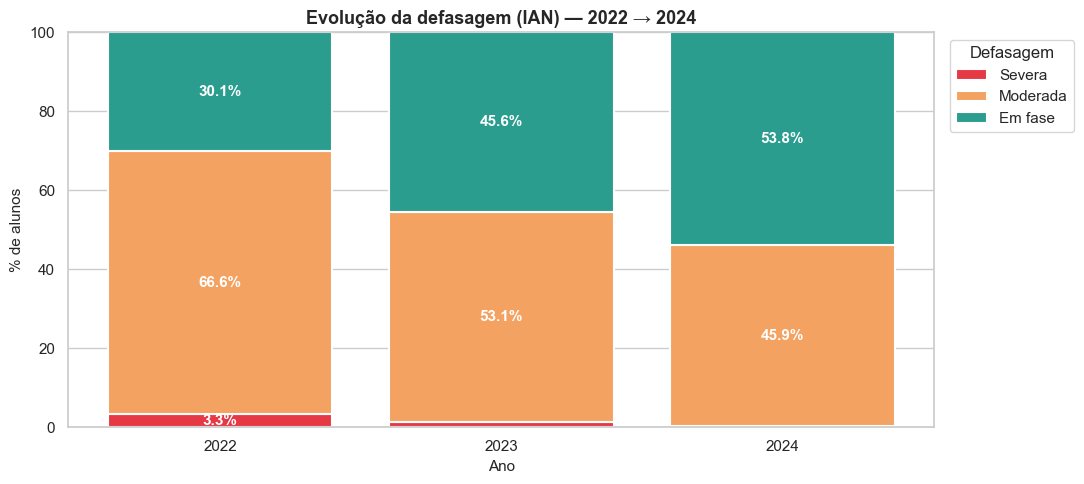

In [4]:
# Visualização: evolução da defasagem ano a ano (barras empilhadas 100%)
fig, ax = plt.subplots(figsize=(11, 5))
cores_ian = ["#e63946", "#f4a261", "#2a9d8f"]  # severa / moderada / em fase

bottom = np.zeros(3)
for i, cat in enumerate(ORDEM_IAN):
    valores = dist_pct[cat].values
    bars = ax.bar(dist_pct.index.astype(str), valores, bottom=bottom,
                  label=cat, color=cores_ian[i], edgecolor="white", linewidth=1.5)
    # Anotar percentuais dentro das barras
    for bar, v, b in zip(bars, valores, bottom):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f"{v:.1f}%", ha="center", va="center",
                    color="white", fontweight="bold", fontsize=11)
    bottom += valores

ax.set_title("Evolução da defasagem (IAN) — 2022 → 2024", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("% de alunos")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="Defasagem")
plt.tight_layout()
salvar_figura("p1_ian_evolucao")
plt.show()

### leitura quantitativa

distribuição da defasagem por ano (IAN):

- 2022: 3.3% severa, 66.6% moderada, 30.1% em fase
- 2023: 1.4% severa, 53.1% moderada, 45.6% em fase
- 2024: 0.3% severa, 45.9% moderada, 53.8% em fase

em 2 anos, a Passos Mágicos quase dobrou a proporção de alunos em fase (30% → 54%) e praticamente eliminou a defasagem severa (3.3% → 0.3%).

  💾 reports/figures/p1_ian_transicao.png


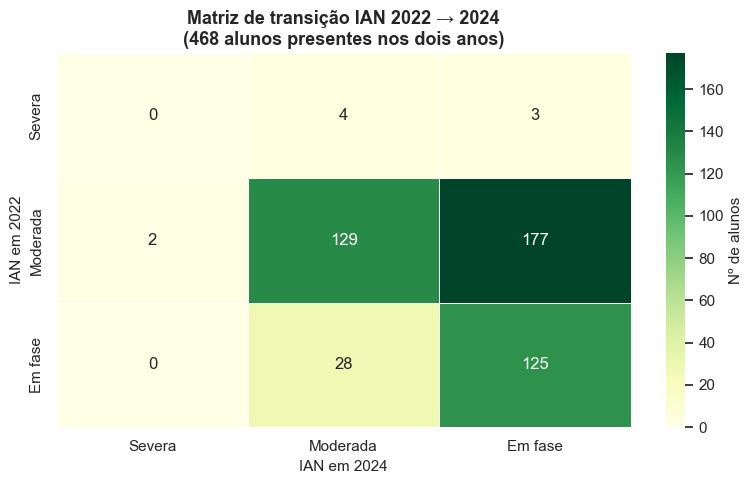


Resumo 2022→2024 (alunos pareados):
transicao
Estável     54.3
Melhorou    39.3
Piorou       6.4


In [5]:
# Visualização adicional: matriz de transição dos alunos que estavam em 22 e 24
ra_22_24 = set(alunos[alunos.ano == 2022].ra) & set(alunos[alunos.ano == 2024].ra)
pareados = (alunos[alunos.ra.isin(ra_22_24)]
            .pivot_table(index="ra", columns="ano", values="ian_cat", aggfunc="first")
            .dropna())

matriz = pd.crosstab(pareados[2022], pareados[2024])
matriz = matriz.reindex(index=ORDEM_IAN, columns=ORDEM_IAN, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="YlGn", cbar_kws={"label": "Nº de alunos"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title(f"Matriz de transição IAN 2022 → 2024\n({len(pareados)} alunos presentes nos dois anos)",
             fontweight="bold")
ax.set_xlabel("IAN em 2024")
ax.set_ylabel("IAN em 2022")
plt.tight_layout()
salvar_figura("p1_ian_transicao")
plt.show()

# Resumo das transições
def classificar(row):
    nivel = {"Severa": 0, "Moderada": 1, "Em fase": 2}
    return "Melhorou" if nivel[row[2024]] > nivel[row[2022]] \
      else "Piorou" if nivel[row[2024]] < nivel[row[2022]] else "Estável"

pareados["transicao"] = pareados.apply(classificar, axis=1)
print("\nResumo 2022→2024 (alunos pareados):")
print((pareados["transicao"].value_counts(normalize=True) * 100).round(1).to_string())

### interpretação

- 39.3% dos alunos acompanhados de 2022 a 2024 melhoraram a categoria de defasagem — 184 de 468. apenas 6.4% pioraram (30 alunos).
- o maior fluxo é moderada → em fase: 177 alunos saíram da defasagem moderada pra alcançar a fase ideal em 2 anos.
- apenas 7 alunos partiram da defasagem severa em 2022 — desses, 3 chegaram a "em fase" e 4 melhoraram pra moderada. zero regrediram dentro da severa (porque a categoria praticamente sumiu).

### o que isso significa pra Passos Mágicos

o programa está cumprindo sua missão histórica. a Passos foi fundada em 1992 pra enfrentar a defasagem escolar — e os números do IAN mostram que ela está vencendo essa batalha. em 2 anos, mais de 1 em cada 3 alunos da base acompanhada saltou de categoria.

esse é o número que vai na primeira linha do relatório anual pra mantenedores e doadores. é a métrica que comunica impacto real em linguagem humana: "tirei 184 crianças da defasagem escolar nos últimos 2 anos."

ressalva metodológica: parte da melhora pode ser efeito de seleção — alunos que evadem tendem a ser os mais defasados, então quem fica é naturalmente quem estava indo melhor. não dá pra atribuir 100% do ganho ao programa sem um grupo controle. mas mesmo com essa ressalva, o movimento é forte demais pra ser só artefato estatístico.

---

## P2 — IDA: o desempenho acadêmico está melhorando, estagnado ou caindo?

contexto: o IDA é a média das notas de matemática, português e inglês. é o indicador mais "duro" do PEDE — mede aprendizagem formal. enquanto o IAN olha onde o aluno está (série/idade), o IDA olha o que ele sabe.

In [6]:
# Evolução geral
ida_por_ano = alunos.groupby("ano")["ida"].agg(["mean", "median", "std", "count"]).round(2)
print("IDA — estatísticas por ano:")
print(ida_por_ano.to_string())

# Evolução por fase
ida_fase_ano = alunos.groupby(["fase", "ano"])["ida"].mean().unstack("ano")
print("\nIDA médio por fase x ano:")
print(ida_fase_ano.round(2).to_string())

IDA — estatísticas por ano:
      mean  median   std  count
ano                            
2022  6.09    6.30  2.05    860
2023  6.66    6.80  1.60    937
2024  6.35    6.75  2.13   1055

IDA médio por fase x ano:
ano   2022  2023  2024
fase                  
0     7.14  7.42  7.32
1     6.46  6.81  6.79
2     5.41  6.74  6.25
3     5.14  5.75  5.35
4     6.05  6.00  5.88
5     5.87  5.90  6.45
6     6.69  6.81  7.23
7     5.25  7.81  5.81
8      NaN   NaN  8.00
9      NaN   NaN   NaN


  💾 reports/figures/p2_ida_evolucao.png


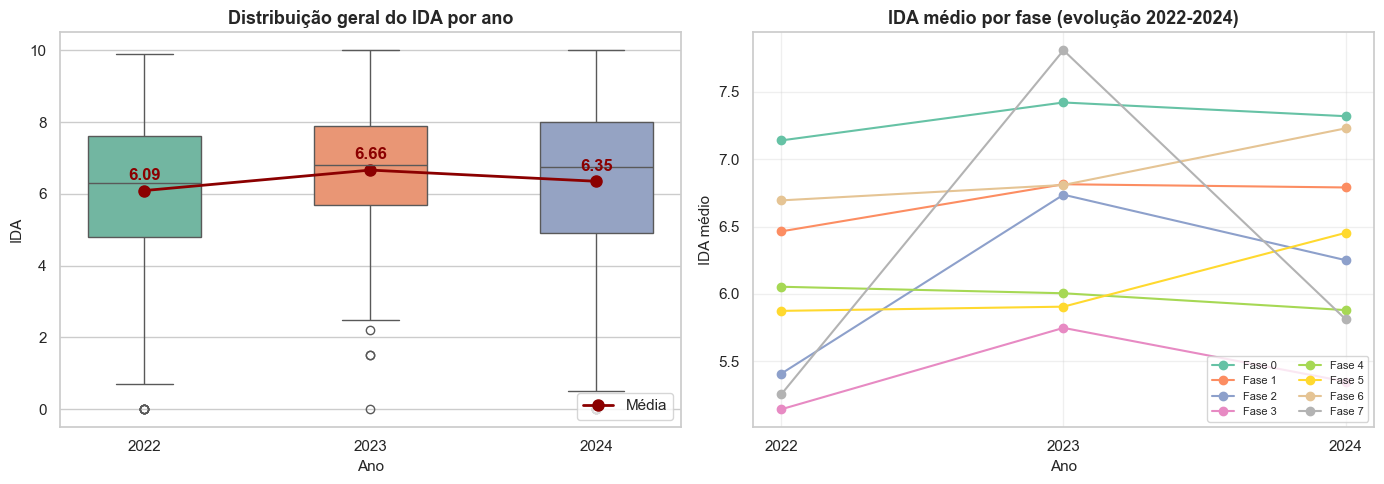

In [7]:
# Visualização: evolução do IDA geral + por fase
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Painel 1: boxplot geral
sns.boxplot(data=alunos, x="ano", y="ida",
            palette=[CORES_ANO[a] for a in [2022, 2023, 2024]],
            ax=ax1, width=0.5)
# Marcar médias
medias = alunos.groupby("ano")["ida"].mean()
ax1.plot([0, 1, 2], medias.values, "o-", color="darkred", markersize=8,
         linewidth=2, label="Média")
for i, m in enumerate(medias.values):
    ax1.text(i, m + 0.3, f"{m:.2f}", ha="center", color="darkred", fontweight="bold")
ax1.set_title("Distribuição geral do IDA por ano", fontweight="bold")
ax1.set_xlabel("Ano")
ax1.set_ylabel("IDA")
ax1.set_ylim(-0.5, 10.5)
ax1.legend(loc="lower right")

# Painel 2: evolução por fase
fases_validas = ida_fase_ano.dropna(how="all").index
for fase in fases_validas:
    if pd.notna(ida_fase_ano.loc[fase]).all():
        ax2.plot(ida_fase_ano.columns, ida_fase_ano.loc[fase].values,
                 marker="o", label=f"Fase {int(fase)}", linewidth=1.5)
ax2.set_title("IDA médio por fase (evolução 2022-2024)", fontweight="bold")
ax2.set_xlabel("Ano")
ax2.set_ylabel("IDA médio")
ax2.set_xticks([2022, 2023, 2024])
ax2.legend(ncol=2, fontsize=8, loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
salvar_figura("p2_ida_evolucao")
plt.show()

In [8]:
# Análise pareada: alunos presentes em 2022 E 2024, delta do IDA
pareados_ida = (alunos[alunos.ra.isin(ra_22_24)]
                .pivot_table(index="ra", columns="ano", values="ida", aggfunc="first")
                .dropna())
pareados_ida["delta"] = pareados_ida[2024] - pareados_ida[2022]

print(f"Alunos com IDA válido em 2022 e 2024: {len(pareados_ida)}")
print(f"\nDelta IDA médio (2024 - 2022): {pareados_ida['delta'].mean():.2f}")
print(f"Mediana do delta: {pareados_ida['delta'].median():.2f}")
print(f"\nDistribuição do delta:")
print(f"  Melhoraram (>0):        {(pareados_ida['delta'] > 0).mean() * 100:.1f}%")
print(f"  Estáveis (-0.5 a 0.5):  {((pareados_ida['delta'] >= -0.5) & (pareados_ida['delta'] <= 0.5)).mean() * 100:.1f}%")
print(f"  Pioraram (<0):          {(pareados_ida['delta'] < 0).mean() * 100:.1f}%")

Alunos com IDA válido em 2022 e 2024: 435

Delta IDA médio (2024 - 2022): -0.47
Mediana do delta: -0.30

Distribuição do delta:
  Melhoraram (>0):        43.9%
  Estáveis (-0.5 a 0.5):  22.1%
  Pioraram (<0):          55.2%


### leitura quantitativa

- IDA médio: 6.09 (2022) → 6.66 (2023) → 6.35 (2024) — subiu forte e depois recuou
- alunos pareados 2022-2024: delta médio é de -0.47 ponto. ou seja, em média, o mesmo aluno está pior em 2024 do que em 2022
- 55.2% dos alunos pareados pioraram o IDA (vs 43.9% que melhoraram)
- fase 3 (7º-8º ano) tem o pior IDA em todos os 3 anos (5.14 → 5.75 → 5.35) — é o buraco crônico do programa

### interpretação

aqui acontece o paradoxo central do projeto:

- pelo IAN, o programa tá ganhando: alunos avançam de série, saem da defasagem (P1 já mostrou).
- pelo IDA, o programa tá perdendo: as notas médias caíram em 2024 e alunos pareados estão em média pior do que em 2022.

as duas coisas podem ser verdade simultaneamente. uma interpretação possível: o programa tá promovendo alunos pra fases mais adiantadas, mas sem conseguir blindar o desempenho acadêmico no salto. ou seja: a ONG consegue tirar da defasagem, mas não consegue manter aprendendo no ritmo da nova série.

### o que isso significa pra Passos Mágicos

a fase 3 (7º-8º ano) é o buraco negro do programa. em todos os 3 anos, é onde o IDA é menor. não é coincidência — é a clássica "crise da 8ª série" da educação brasileira: adolescência + transição pra matemática mais abstrata + pressão social. a Passos precisa de intervenção pedagógica direcionada pra essa fase específica.

o IDA caindo em 2024 é um alerta amarelo. precisa investigar se é: (a) efeito da expansão do programa (mais alunos novos, qualidade diluída), (b) fadiga pós-pandemia persistente, ou (c) mudança na composição etária. qualquer que seja a causa, monitoramento mensal do IDA das fases 3-4 devia entrar no dashboard de acompanhamento da coordenação pedagógica.

---

## P3 — IEG: engajamento tem relação direta com IDA e IPV?

contexto: o IEG mede a entrega de tarefas e a participação — é o indicador de "esforço" do aluno. a hipótese é que aluno engajado aprende mais (IDA alto) e avança mais (IPV alto). mas o quanto, exatamente?

  💾 reports/figures/p3_ieg_correlacoes.png


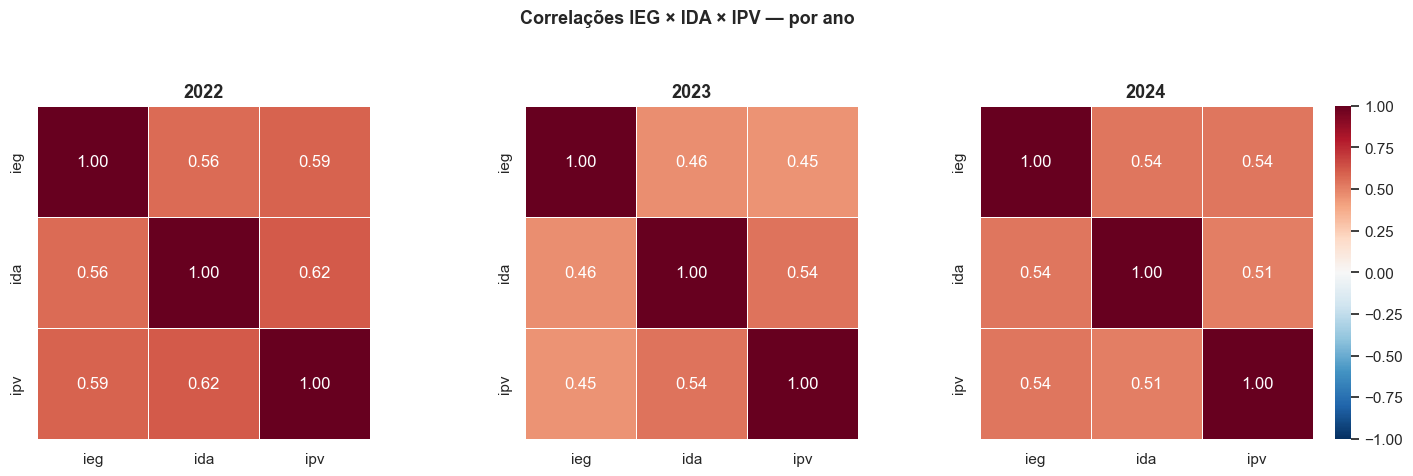

In [9]:
# Correlações IEG x IDA x IPV por ano
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, ano in zip(axes, [2022, 2023, 2024]):
    df = alunos[alunos.ano == ano][["ieg", "ida", "ipv"]].corr()
    sns.heatmap(df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, cbar=ax == axes[-1],
                linewidths=0.5, ax=ax)
    ax.set_title(f"{ano}", fontweight="bold")
plt.suptitle("Correlações IEG × IDA × IPV — por ano", fontsize=13, y=1.05, fontweight="bold")
plt.tight_layout()
salvar_figura("p3_ieg_correlacoes")
plt.show()

  💾 reports/figures/p3_ieg_ida_ipv.png


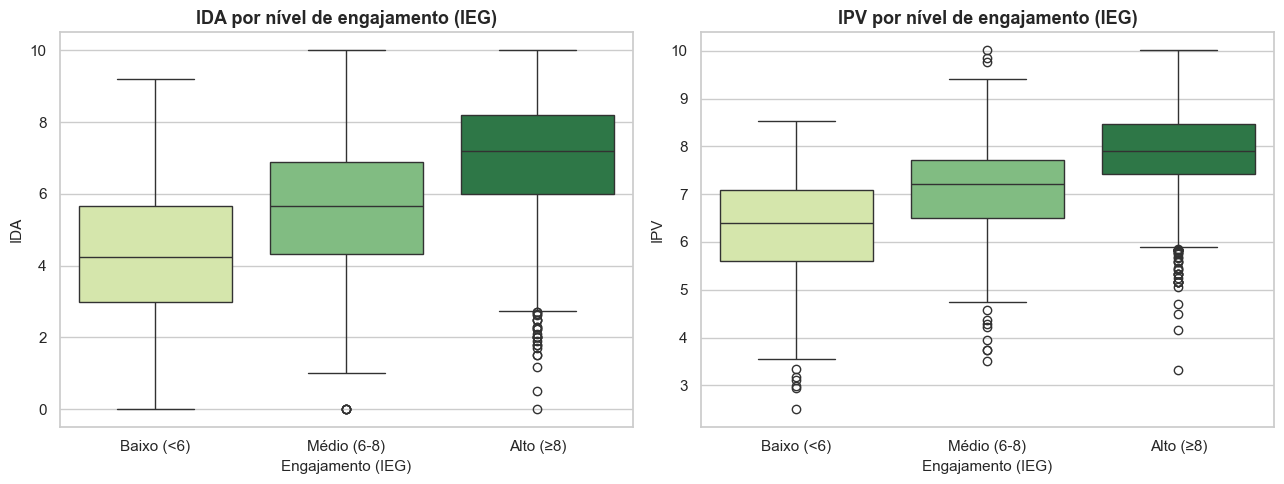

In [10]:
# Categorizar IEG e ver o que acontece com IDA e IPV
alunos["ieg_cat"] = pd.cut(alunos["ieg"], bins=[0, 6, 8, 10.1],
                           labels=["Baixo (<6)", "Médio (6-8)", "Alto (≥8)"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: IDA por faixa de IEG
sns.boxplot(data=alunos.dropna(subset=["ieg_cat"]),
            x="ieg_cat", y="ida", palette="YlGn", ax=ax1)
ax1.set_title("IDA por nível de engajamento (IEG)", fontweight="bold")
ax1.set_xlabel("Engajamento (IEG)")
ax1.set_ylabel("IDA")

# Painel 2: IPV por faixa de IEG
sns.boxplot(data=alunos.dropna(subset=["ieg_cat"]),
            x="ieg_cat", y="ipv", palette="YlGn", ax=ax2)
ax2.set_title("IPV por nível de engajamento (IEG)", fontweight="bold")
ax2.set_xlabel("Engajamento (IEG)")
ax2.set_ylabel("IPV")

plt.tight_layout()
salvar_figura("p3_ieg_ida_ipv")
plt.show()

In [11]:
# O número matador: % de alunos no top25 do IPV por nível de IEG
ipv_top_threshold = alunos["ipv"].quantile(0.75)
print(f"Threshold top25 do IPV: {ipv_top_threshold:.2f}\n")

alunos["ipv_top25"] = alunos["ipv"] >= ipv_top_threshold
top25_por_ieg = alunos.groupby("ieg_cat", observed=False)["ipv_top25"].mean() * 100

print("% de alunos no top25 do IPV, por nível de engajamento:")
for cat in ["Baixo (<6)", "Médio (6-8)", "Alto (≥8)"]:
    print(f"  IEG {cat:15s}: {top25_por_ieg[cat]:5.1f}%")

razao = top25_por_ieg["Alto (≥8)"] / top25_por_ieg["Baixo (<6)"]
print(f"\n→ Alunos com IEG alto têm {razao:.1f}x mais chance de estar no top25 do IPV")

Threshold top25 do IPV: 8.26

% de alunos no top25 do IPV, por nível de engajamento:
  IEG Baixo (<6)     :   1.4%
  IEG Médio (6-8)    :  10.3%
  IEG Alto (≥8)      :  34.5%

→ Alunos com IEG alto têm 24.1x mais chance de estar no top25 do IPV


### leitura quantitativa

- correlações estáveis ao longo dos anos: IEG ↔ IDA ≈ 0.46-0.56, IEG ↔ IPV ≈ 0.45-0.59. são correlações moderadas a fortes.
- alunos com IEG baixo (<6): apenas 1.4% estão no top 25% do IPV
- alunos com IEG alto (≥8): 34.5% estão no top 25% do IPV
- diferença: ~24x

### interpretação

o engajamento não garante o ponto de virada (só 1 em cada 3 alunos engajados chega ao top25), mas ele é pré-requisito quase absoluto: quem não engaja, praticamente nunca vira a chave. a correlação não é 1.0 — engajamento é condição necessária mas não suficiente.

### o que isso significa pra Passos Mágicos

engajamento é o melhor early warning que a ONG tem. um aluno que para de entregar tarefas é um sinal antecipado de risco — muito antes do IDA refletir a queda. monitorar IEG mensalmente permite intervenção antes do prejuízo acadêmico se consolidar.

recomendação: criar um alerta automático pra quando o IEG de um aluno cair mais de 1.5 pontos em um trimestre. isso deve disparar uma conversa do tutor com o aluno antes da queda chegar no IDA. o número "1.4% → 34.5%" é impressionante o suficiente pra justificar investimento em sistema de monitoramento contínuo de engajamento.

---

## P4 — IAA: a autoavaliação dos alunos é coerente com o desempenho real?

contexto: o IAA é a média das notas que o aluno dá pra si mesmo numa autoavaliação (escala 0-10). se os alunos têm boa autoconsciência, o IAA deveria correlacionar fortemente com o IDA (desempenho real). se não, tem uma lição importante aí.

In [12]:
# Calcular o gap
alunos["gap_iaa_ida"] = alunos["iaa"] - alunos["ida"]

def cat_gap(g):
    if pd.isna(g):
        return np.nan
    if g < -1:
        return "Subestima (<-1)"
    elif g <= 1:
        return "Calibrado (±1)"
    elif g <= 3:
        return "Superestima leve (1-3)"
    return "Superestima forte (>3)"


alunos["gap_cat"] = alunos["gap_iaa_ida"].apply(cat_gap)

print("Distribuição do gap IAA - IDA:")
dist_gap = alunos["gap_cat"].value_counts()
pct_gap = (dist_gap / dist_gap.sum() * 100).round(1)
for cat in ["Subestima (<-1)", "Calibrado (±1)",
            "Superestima leve (1-3)", "Superestima forte (>3)"]:
    if cat in dist_gap.index:
        print(f"  {cat:25s}: {dist_gap[cat]:4d} ({pct_gap[cat]:.1f}%)")

print(f"\n→ TOTAL SUPERESTIMA: {pct_gap.get('Superestima leve (1-3)', 0) + pct_gap.get('Superestima forte (>3)', 0):.1f}%")
print(f"→ Correlação IAA x IDA: {alunos[['iaa','ida']].corr().iloc[0,1]:.3f}")

Distribuição do gap IAA - IDA:
  Subestima (<-1)          :  328 (11.5%)
  Calibrado (±1)           :  660 (23.1%)
  Superestima leve (1-3)   : 1002 (35.1%)
  Superestima forte (>3)   :  861 (30.2%)

→ TOTAL SUPERESTIMA: 65.3%
→ Correlação IAA x IDA: 0.115


  💾 reports/figures/p4_iaa_gap.png


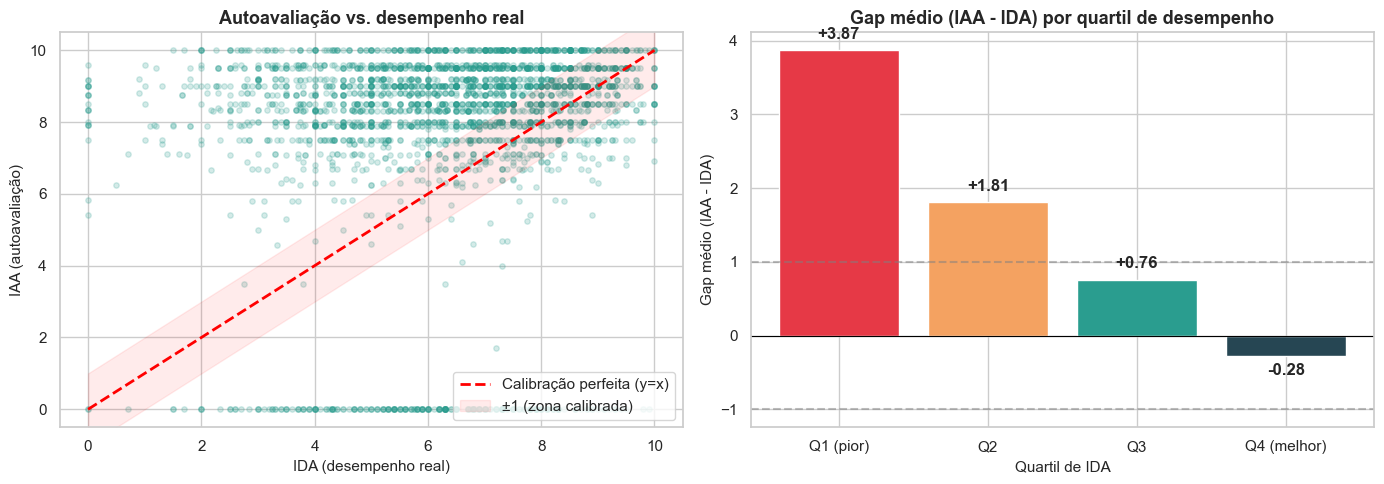

In [13]:
# Visualização: scatter IAA vs IDA com linha de referência
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Painel 1: scatter
sub = alunos.dropna(subset=["iaa", "ida"])
ax1.scatter(sub["ida"], sub["iaa"], alpha=0.2, s=15, color="#2a9d8f")
ax1.plot([0, 10], [0, 10], "r--", linewidth=2, label="Calibração perfeita (y=x)")
ax1.fill_between([0, 10], [-1, 9], [1, 11], color="red", alpha=0.08, label="±1 (zona calibrada)")
ax1.set_xlabel("IDA (desempenho real)")
ax1.set_ylabel("IAA (autoavaliação)")
ax1.set_title("Autoavaliação vs. desempenho real", fontweight="bold")
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-0.5, 10.5)
ax1.legend(loc="lower right")

# Painel 2: gap médio por quartil de IDA
alunos["ida_quartil"] = pd.qcut(alunos["ida"], q=4,
                                labels=["Q1 (pior)", "Q2", "Q3", "Q4 (melhor)"])
gap_por_quartil = (alunos.groupby("ida_quartil", observed=False)["gap_iaa_ida"]
                   .mean().round(2))

bars = ax2.bar(gap_por_quartil.index.astype(str),
               gap_por_quartil.values,
               color=["#e63946", "#f4a261", "#2a9d8f", "#264653"])
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(1, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(-1, color="gray", linestyle="--", alpha=0.5)
ax2.set_title("Gap médio (IAA - IDA) por quartil de desempenho", fontweight="bold")
ax2.set_xlabel("Quartil de IDA")
ax2.set_ylabel("Gap médio (IAA - IDA)")
for bar, v in zip(bars, gap_por_quartil.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.15 if v >= 0 else -0.25),
             f"{v:+.2f}", ha="center", fontweight="bold")

plt.tight_layout()
salvar_figura("p4_iaa_gap")
plt.show()

### leitura quantitativa

- 65.3% dos alunos superestimam seu próprio desempenho (35.1% levemente + 30.2% fortemente)
- apenas 23.1% estão calibrados (gap dentro de ±1)
- alunos no quartil pior de IDA superestimam em média 3.87 pontos — dão pra si mesmos nota ~4 pontos maior do que a real
- alunos no quartil melhor são os únicos calibrados (gap médio de -0.28)
- correlação IAA × IDA = 0.115 — praticamente zero, estatisticamente significante mas praticamente irrelevante

### interpretação

isso não é só "alunos são otimistas demais" — é um fenômeno psicológico bem estudado: o efeito Dunning-Kruger, onde pessoas menos competentes em algo tendem a superestimar mais sua própria competência, porque lhes falta a metacognição necessária pra avaliar o próprio nível.

os alunos que estão mais mal academicamente são exatamente os que menos sabem que estão mal. tem implicação pedagógica pesada: eles não pedem ajuda porque acham que não precisam.

### o que isso significa pra Passos Mágicos

feedback formativo na Passos Mágicos precisa ser explícito, quantitativo e frequente. não adianta dizer "você pode melhorar" — o aluno já acha que tá ótimo. é preciso mostrar números: "sua média em matemática é 4.5, a média da sua turma é 6.8, você precisa chegar em 7 pra avançar".

recomendação: criar um ritual de devolutiva estruturada a cada trimestre, onde cada aluno recebe um boletim comparativo com o próprio desempenho vs. meta + posição na turma. não pra gerar competição tóxica, mas pra calibrar a percepção. a autoconsciência precisa ser construída ativamente — ela não vem sozinha.

esse é potencialmente o insight de maior valor pedagógico do projeto inteiro. tem implicação direta em como a ONG deveria desenhar a rotina de feedback.

---

## P5 — IPS: padrões psicossociais que antecedem quedas

contexto: o IPS é avaliado por psicólogos (comportamental/emocional/social). a hipótese da Passos é que alunos com IPS baixo em um ano tendem a ter queda de desempenho no ano seguinte. vou testar isso e, de quebra, investigar a anomalia de 2023 detectada na etapa 2.

### 5.1 primeiro: entendendo a anomalia de 2023

In [14]:
# Confirmar a anomalia e verificar em quais fases ela se concentra
ips_fase_ano = alunos.groupby(["fase", "ano"])["ips"].median().unstack("ano")
print("Mediana do IPS por fase e ano:")
print(ips_fase_ano.round(2).to_string())

# % de alunos no piso (IPS <= 3) por ano
print("\nAlunos no piso do IPS (IPS <= 3):")
for ano in [2022, 2023, 2024]:
    s = alunos[alunos.ano == ano]["ips"].dropna()
    piso = (s <= 3).sum()
    pct = piso / len(s) * 100
    print(f"  {ano}: {piso}/{len(s)} alunos ({pct:.1f}%)")

Mediana do IPS por fase e ano:
ano   2022  2023  2024
fase                  
0      7.5  7.52  7.51
1      7.5  7.52  7.51
2      7.5  5.00  7.51
3      7.5  5.00  7.51
4      6.3  2.52  6.26
5      7.5  5.00  6.26
6      8.1  5.63  7.51
7      6.3  5.00  6.88
8      NaN   NaN   NaN
9      NaN   NaN   NaN

Alunos no piso do IPS (IPS <= 3):
  2022: 1/860 alunos (0.1%)
  2023: 265/945 alunos (28.0%)
  2024: 58/1054 alunos (5.5%)


  💾 reports/figures/p5_ips_heatmap.png


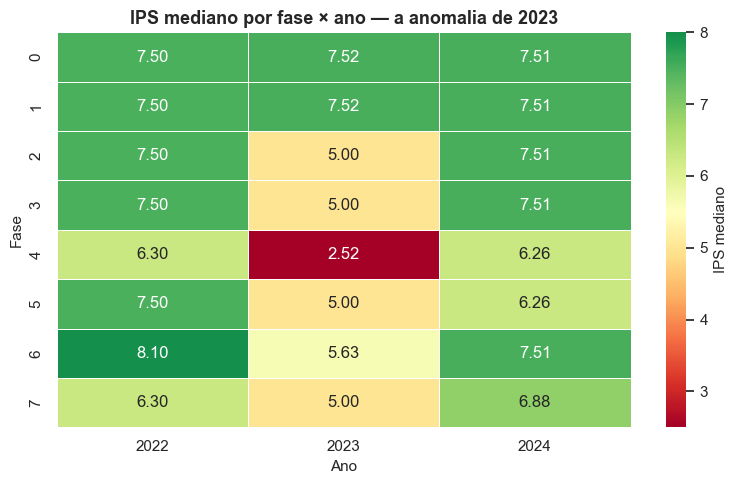

In [15]:
# Visualização: heatmap do IPS mediano por fase x ano
fig, ax = plt.subplots(figsize=(8, 5))
dados_validos = ips_fase_ano.dropna(how="all")
sns.heatmap(dados_validos, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=2.5, vmax=8, center=5.5, linewidths=0.5, ax=ax,
            cbar_kws={"label": "IPS mediano"})
ax.set_title("IPS mediano por fase × ano — a anomalia de 2023", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Fase")
plt.tight_layout()
salvar_figura("p5_ips_heatmap")
plt.show()

### diagnóstico da anomalia

a anomalia de 2023 não é uniforme — ela se concentra nas fases 2 a 7 (ensino fundamental II + médio). as fases 0 e 1 (ALFA e fase 1, crianças menores) mantiveram o IPS normal em 2023 (mediana 7.52).

28% dos alunos em 2023 estão no piso do IPS (≤3) — contra 0.1% em 2022 e 5.5% em 2024. são 265 alunos que caíram artificialmente pra perto de zero em um único ano.

três hipóteses mais plausíveis (só a Passos poderia confirmar qual é a certa):

1. nova equipe de psicologia em 2023 com critérios de avaliação mais rigorosos pras fases mais velhas
2. mudança no protocolo de avaliação só pra alunos de 10+ anos (novo instrumento aplicado)
3. incidente/evento específico que afetou a saúde mental das turmas maiores em 2023 (e se recuperou em 2024)

decisão metodológica: não vou usar IPS bruto como feature do modelo preditivo — vou normalizar por ano (z-score dentro do ano), pra comparar alunos dentro do mesmo universo de avaliação.

### 5.2 IPS prediz quedas futuras?

In [16]:
# Construir pares (t, t+1): alunos com dado em dois anos consecutivos
def construir_pares(df, ano_t, ano_tp1):
    t = df[df.ano == ano_t][["ra", "ips", "inde"]].rename(
        columns={"ips": "ips_t", "inde": "inde_t"})
    tp = df[df.ano == ano_tp1][["ra", "inde"]].rename(
        columns={"inde": "inde_tp1"})
    return t.merge(tp, on="ra", how="inner").dropna()


pares_22_23 = construir_pares(alunos, 2022, 2023)
pares_23_24 = construir_pares(alunos, 2023, 2024)

pares_22_23["delta_inde"] = pares_22_23["inde_tp1"] - pares_22_23["inde_t"]
pares_23_24["delta_inde"] = pares_23_24["inde_tp1"] - pares_23_24["inde_t"]

print("Correlação entre IPS em t e delta INDE (t → t+1):")
print(f"  22 → 23: {pares_22_23[['ips_t','delta_inde']].corr().iloc[0,1]:+.3f}  (n={len(pares_22_23)})")
print(f"  23 → 24: {pares_23_24[['ips_t','delta_inde']].corr().iloc[0,1]:+.3f}  (n={len(pares_23_24)})")
print("\n→ As correlações são fracas/irrelevantes.")
print("→ IPS bruto NÃO é bom preditor de queda futura de INDE.")

Correlação entre IPS em t e delta INDE (t → t+1):
  22 → 23: -0.021  (n=570)
  23 → 24: -0.156  (n=678)

→ As correlações são fracas/irrelevantes.
→ IPS bruto NÃO é bom preditor de queda futura de INDE.


### o que isso significa pra Passos Mágicos

o IPS como está hoje não serve pra identificar alunos em risco. tanto porque a anomalia de 2023 corrompe comparações temporais, quanto porque a correlação com o delta INDE é fraca mesmo nos anos limpos (2022→2023 correlação = -0.02, praticamente zero).

recomendações:

1. investigar a origem da anomalia de 2023 — se foi mudança de equipe ou protocolo, documentar a quebra pra futuros dashboards comparativos
2. revisar o instrumento de avaliação psicossocial — se ele não prediz risco, precisa ser redesenhado ou complementado
3. considerar substituir por indicadores comportamentais observáveis (faltas, atrasos, conflitos registrados) que têm evidência empírica melhor de preditividade

limitação metodológica: estou olhando IPS de um ano inteiro prevendo delta INDE. pode ser que o IPS a nível mensal ou trimestral preveja queda dentro do mesmo ano — não dá pra testar com os dados que tenho.

---

## P6 — IPP: a avaliação psicopedagógica confirma ou contradiz a defasagem formal?

contexto: o IPP é a avaliação feita por psicopedagogos — um olhar qualificado sobre a capacidade de aprendizagem do aluno. a pergunta é: ele confirma o quadro do IAN (defasagem formal) ou contradiz?

limitação: o IPP só existe em 2023 e 2024 no dataset. análises longitudinais ficam restritas a esse período.

In [17]:
# IPP só está preenchido em 2023 e 2024
df_ipp = alunos[alunos["ipp"].notna() & alunos["ian_cat"].notna()].copy()

# IPP médio por categoria IAN
ipp_por_ian = df_ipp.groupby("ian_cat")["ipp"].agg(["mean", "median", "std", "count"]).round(2)
ipp_por_ian = ipp_por_ian.reindex(["Em fase", "Moderada", "Severa"])
print("IPP por categoria de IAN:")
print(ipp_por_ian.to_string())

# Correlação
corr_ipp_ian = df_ipp[["ipp", "ian"]].corr().iloc[0, 1]
print(f"\nCorrelação IPP x IAN: {corr_ipp_ian:+.3f}")

IPP por categoria de IAN:
          mean  median   std  count
ian_cat                            
Em fase   7.68    7.71  0.89    908
Moderada  7.46    7.50  0.96   1067
Severa    7.01    7.50  1.13     17

Correlação IPP x IAN: +0.123


  💾 reports/figures/p6_ipp_ian.png


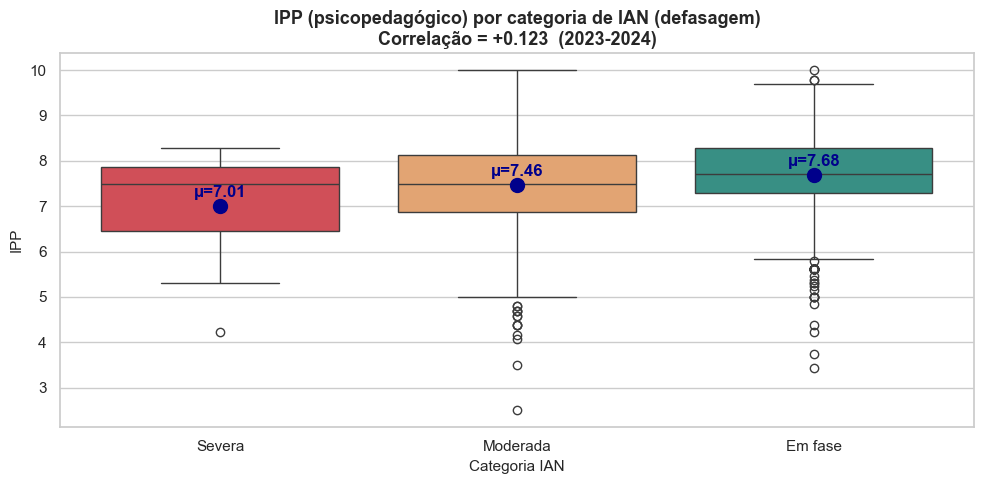

In [18]:
# Visualização: boxplot IPP por categoria IAN
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_ipp, x="ian_cat", y="ipp",
            order=["Severa", "Moderada", "Em fase"],
            palette=["#e63946", "#f4a261", "#2a9d8f"], ax=ax)

# Marcar as médias
medias = df_ipp.groupby("ian_cat")["ipp"].mean()
for i, cat in enumerate(["Severa", "Moderada", "Em fase"]):
    if cat in medias.index:
        ax.plot(i, medias[cat], "o", color="darkblue", markersize=10, zorder=10)
        ax.text(i, medias[cat] + 0.2, f"μ={medias[cat]:.2f}",
                ha="center", fontweight="bold", color="darkblue")

ax.set_title("IPP (psicopedagógico) por categoria de IAN (defasagem)\n"
             f"Correlação = {corr_ipp_ian:+.3f}  (2023-2024)", fontweight="bold")
ax.set_xlabel("Categoria IAN")
ax.set_ylabel("IPP")
plt.tight_layout()
salvar_figura("p6_ipp_ian")
plt.show()

In [19]:
# Casos "contraditórios"
em_fase_ipp_baixo = df_ipp[(df_ipp["ian_cat"] == "Em fase") & (df_ipp["ipp"] < 6)]
severa_ipp_alto = df_ipp[(df_ipp["ian_cat"] == "Severa") & (df_ipp["ipp"] >= 8)]

print(f"Casos 'interessantes':")
print(f"  'Em fase' com IPP < 6 (risco oculto?):  {len(em_fase_ipp_baixo)} alunos")
print(f"  'Severa' com IPP ≥ 8 (talento não explorado?):  {len(severa_ipp_alto)} alunos")

Casos 'interessantes':
  'Em fase' com IPP < 6 (risco oculto?):  53 alunos
  'Severa' com IPP ≥ 8 (talento não explorado?):  2 alunos


### leitura quantitativa

IPP médio por categoria de IAN:

- em fase: 7.68 (n=908)
- moderada: 7.46 (n=1067)
- severa: 7.01 (n=17)

- diferença entre "em fase" e "severa": apenas 0.67 ponto de IPP
- correlação IPP × IAN = 0.12 — fraca
- 53 alunos estão "em fase" (IAN alto) mas com IPP < 6 — risco oculto
- 2 alunos estão com defasagem severa mas IPP ≥ 8 — talento potencial não alcançado pela defasagem formal

### interpretação

IPP e IAN medem coisas diferentes. faz sentido que exista alguma correlação (a direção está certa: severa < moderada < em fase), mas a magnitude é pequena.

o olhar psicopedagógico é muito mais generoso que o critério formal de defasagem por idade/série. a psicopedagoga pode ver um aluno defasado que tem raciocínio brilhante e pontuar alto — o que é correto sob a ótica dela. mas isso significa que:

- IPP alto não descarta defasagem — um aluno pode ter IPP 8 e ainda estar no 7º ano com 14 anos
- IAN severa não significa incapacidade — 2 alunos provam isso no dataset

### o que isso significa pra Passos Mágicos

IPP e IAN são indicadores complementares, não redundantes. olhar só pro IAN (defasagem formal) perde o lado qualitativo. olhar só pro IPP perde a urgência da correção de série.

os 53 alunos "em fase" mas com IPP baixo merecem atenção especial: são alunos que a estrutura formal não está capturando como risco, mas a psicopedagoga sinaliza que precisam de apoio. são falsos negativos do IAN. esses casos são fortes candidatos a entrar na lista de alunos de intervenção prioritária.

recomendação: o dashboard de acompanhamento da Passos deveria incluir um alerta de divergência IPP × IAN — alunos onde os dois indicadores discordam significativamente. eles são exatamente os casos onde o olhar humano especializado está vendo algo que os indicadores formais não capturam.

---

## resumo da etapa 3a

os 6 grandes achados das perguntas 1-6:

- P1 — alunos "em fase" dobraram em 2 anos (30% → 54%). impacto bruto do programa.
- P2 — paradoxo: IAN melhora mas IDA cai. fase 3 é o buraco crônico. alerta amarelo.
- P3 — IEG alto gera 24× mais chance de estar no top25 do IPV. melhor early warning.
- P4 — 65% dos alunos superestimam seu desempenho; correlação IAA × IDA é 0.12. Dunning-Kruger confirmado.
- P5 — anomalia de 2023 concentrada nas fases 2-7 (28% no piso). IPS não prediz queda. dado precisa normalização.
- P6 — IPP e IAN são complementares — 53 alunos "em fase" com IPP baixo são risco oculto. ajuste do dashboard.

insights mais fortes pra apresentação executiva:

1. P1: "a Passos tirou 184 crianças da defasagem escolar em 2 anos" — manchete do relatório anual
2. P4: "65% dos alunos acham que estão melhores do que estão" — implicação pedagógica direta
3. P3: "24× mais chance de sucesso pra quem engaja" — justifica investimento em sistema de monitoramento

próxima entrega (3b):

- P7 — IPV: o que mais influencia o ponto de virada? (feature importance preliminar)
- P8 — multidimensionalidade: que combinações de indicadores elevam o INDE?
- P9 — efetividade: a jornada Quartzo → Topázio funciona?
- P10 — insight livre: análise de evasão (256 alunos que sumiram entre 2022 e 2023)
- P11 — insight livre: a crise da fase 3 + o vácuo do ensino superior

próximo passo: validar essa entrega e partir pra etapa 3b — perguntas 7 a 11.